# Shot Quality Model - Exploratory Data Analysis

## Purpose
EDA for defensive shot quality model predicting 3P% allowed using:
- Rim protection, drives allowed, corner 3 residual, expected shot quality
- Attendance % as crowd pressure proxy

## EDA Structure
1. Distributions (raw makes, attempts, efficiency)
2. Sample size vs variance relationship
3. Feature correlations
4. Residual construction + predictive validation
5. Time series + autocorrelation
6. Bivariate relationships to outcome
7. Splits (home/away, rest, opponent tier)
8. Attendance % analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)



In [3]:
#nba module and data import
import nba_api
from nba import NBAbase, NBAetl, NBAdata, NBAmodels
etl = NBAetl.etl()
data = NBAdata.data()

In [107]:
threes = NBAmodels.models('threes')

td = data.threes_pipe(threes.data)

td = data.clean_na(td)
# td = td[td.game_date<='2025-10-01']
#td = threes.standRobust_scaler(td)
#preds= threes.model.predict(sm.add_constant(td.filter(threes.features),has_constant='add'))

In [85]:
pd.read_sql('select * from teamLog',etl.conn)

,game_id,game_date,team_id,opp_id,attendance,home,inactive,count_inactive,assist_percentage,offensive_rating,defensive_rating,pace,possessions,off_rb_pct,def_rb_pct,second_chance_points,sc_points_allowed,points_fast_break,fb_points_allowed,points_off_turnovers,to_points_allowed,bench_points,bp_allowed,biggest_lead,biggest_deficit,biggest_run,biggest_run_allowed,time_leading,times_tied,q1_pts,q2_pts,q3_pts,q4_pts,ot1_pts,ot2_pts,ot3_pts,ot4_pts,win,season
0,0022500418,2025-12-23,1610612756,1610612747,17071.0,1,"1628960,1642886,1630224,1630587",4.0,0.700,138.9,112.5,95.5,95.0,0.342,0.638,7.0,9.0,13.0,5.0,24.0,14.0,40.0,35.0,32.0,5.0,6.0,9.0,PT39M32.00S,6.0,29.0,38.0,45.0,20.0,NaN,NaN,None,None,1.0,2025-26
1,0022500418,2025-12-23,1610612747,1610612756,0.0,0,"1629029,1629060,1631166,1629216",4.0,0.564,112.5,138.9,95.5,96.0,0.362,0.658,9.0,7.0,5.0,13.0,14.0,24.0,35.0,40.0,5.0,32.0,9.0,6.0,PT05M41.00S,6.0,26.0,31.0,29.0,22.0,NaN,NaN,None,None,0.0,2025-26
2,0022500420,2025-12-23,1610612757,1610612753,17073.0,1,"1630703,201950,1631104",3.0,0.561,108.2,111.1,98.5,98.0,0.333,0.714,7.0,4.0,28.0,13.0,14.0,22.0,28.0,23.0,1.0,17.0,13.0,13.0,PT00M41.00S,1.0,21.0,29.0,30.0,26.0,NaN,NaN,None,None,0.0,2025-26
3,0022500420,2025-12-23,1610612753,1610612757,0.0,0,"1629048,1630658,1641783,1630591,1630532,1629021",6.0,0.703,111.1,108.2,98.5,99.0,0.286,0.667,4.0,7.0,13.0,28.0,22.0,14.0,23.0,28.0,17.0,1.0,13.0,13.0,PT46M50.00S,1.0,25.0,38.0,26.0,21.0,NaN,NaN,None,None,1.0,2025-26
4,0022500414,2025-12-23,1610612748,1610612761,19801.0,1,"1642884,1626179,1642443",3.0,0.545,95.8,119.1,94.5,95.0,0.294,0.638,4.0,8.0,13.0,17.0,20.0,22.0,43.0,36.0,2.0,23.0,8.0,10.0,PT00M43.00S,5.0,16.0,28.0,23.0,24.0,NaN,NaN,None,None,0.0,2025-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9835,0022500903,2026-03-05,1610612761,1610612750,0.0,0,"1642935,1630639,1642918,1642867",4.0,0.537,111.5,117.3,97.0,96.0,0.250,0.698,4.0,5.0,14.0,15.0,21.0,26.0,25.0,34.0,12.0,18.0,13.0,11.0,PT16M57.60S,6.0,27.0,27.0,22.0,31.0,NaN,NaN,None,None,0.0,2025-26
9836,0022500905,2026-03-05,1610612756,1610612741,17071.0,1,"1642886,1628415,1630692,1630587,1631109",5.0,0.667,100.0,101.9,103.0,103.0,0.295,0.796,4.0,2.0,10.0,22.0,13.0,12.0,46.0,24.0,0.0,12.0,8.0,7.0,PT00M00.00S,1.0,20.0,30.0,27.0,26.0,NaN,NaN,None,None,0.0,2025-26
9837,0022500905,2026-03-05,1610612741,1610612756,0.0,0,"1628380,1642855,1631093,1629014,1630188,1630172",6.0,0.561,101.9,100.0,103.0,103.0,0.204,0.705,2.0,4.0,22.0,10.0,12.0,13.0,24.0,46.0,12.0,0.0,7.0,8.0,PT45M55.00S,1.0,24.0,31.0,28.0,22.0,NaN,NaN,None,None,1.0,2025-26
9838,0022500906,2026-03-05,1610612743,1610612747,19947.0,1,"203932,1629661,1642938,1642461,1642354,1631212",6.0,0.692,121.2,116.5,98.0,99.0,0.300,0.841,7.0,4.0,11.0,22.0,11.0,26.0,26.0,45.0,15.0,0.0,11.0,12.0,PT47M41.00S,0.0,32.0,32.0,29.0,27.0,NaN,NaN,None,None,1.0,2025-26


In [38]:
tracking = pd.read_sql('''SELECT opp_id as team_id, game_date,
                        sum(drive_fga) as drive_fga_allowed, sum(drive_passes) as drive_passes_allowed,
                        sum(drive_assists) as drive_assists_allowed, sum(drive_to) as drive_to_forced,
                        sum(drive_fouls_drawn) as drive_fouls_given, sum(assist_pts_created) as assisted_pts_allowed,
                        sum(adjusted_assists) as adjusted_assists_allowed, sum(drive_fgm) / sum(drive_fga) as drive_sht_prct_allowed,
                        sum(catchshoot_fg3m) as cs_fg3m_allowed, sum(catchshoot_fg3a) as cs_fg3a_allowed
                        FROM playerTracking
                        GROUP BY opp_id, game_date,team_id''',etl.conn)

In [5]:
pd.read_sql('select * from team_def limit 1 ',etl.conn).columns

Index(['season', 'month', 'team', 'game_number', 'daysBetweenGames',
       'games_in_five', 'games_in_three', 'open3_rate', 'wide3_rate',
       'open2_rate', 'wide2_rate', 'RAAllowedVsAvg', 'PaintAllowedVsAvg',
       'MidAllowedVsAvg', 'ThreesAllowedVsAvg', 'count_inactive',
       'defensive_rating', 'pace', 'points_allowed', 'win', 'home', 'team_id',
       'game_date', 'game_id', 'ra_fgm', 'ra_fga', 'paint_fgm', 'paint_fga',
       'mid_fgm', 'mid_fga', 'lc_fgm', 'lc_fga', 'rc_fgm', 'rc_fga', 'abv_fgm',
       'abv_fga', 'crn_fgm', 'crn_fga', 'wide_fg2m', 'wide_fg2a', 'wide_fg3m',
       'wide_fg3a', 'open_fg2m', 'open_fg2a', 'open_fg3m', 'open_fg3a',
       'drb0_fg2m', 'drb0_fg2a', 'drb0_fg3m', 'drb0_fg3a', 'drb1_fg2m',
       'drb1_fg2a', 'drb1_fg3m', 'drb1_fg3a', 'drb2_fg2m', 'drb2_fg2a',
       'drb2_fg3m', 'drb2_fg3a', 'drb36_fg2m', 'drb36_fg2a', 'drb36_fg3m',
       'drb36_fg3a', 'drb7_fg2m', 'drb7_fg2a', 'drb7_fg3m', 'drb7_fg3a',
       'threes_fga'],
      dtype='object'

In [129]:
shooting = pd.read_sql('''
SELECT
team_id, game_id, game_date, team, season,open3_rate, wide3_rate, RAAllowedVsAvg as ra_residual, PaintAllowedVsAvg as paint_residual,
MidAllowedVsAvg as mid_residual, ThreesAllowedVsAvg as three_residual, (lc_fgm + rc_fgm + abv_fgm) as threes_made, (lc_fga + rc_fga + abv_fga) 
as threes_att,defensive_rating, pace, points_allowed, home, ra_fgm, ra_fga,paint_fgm, paint_fga,mid_fgm, mid_fga, lc_fgm, lc_fga, rc_fgm,
rc_fga, abv_fgm,abv_fga, crn_fgm, crn_fga, wide_fg2m, wide_fg2a, wide_fg3m, wide_fg3a, open_fg2m, open_fg2a, open_fg3m, open_fg3a
FROM team_def
WHERE game_date <= '2026-02-27'
''',etl.conn)

In [130]:
shooting['three_percentage'] = shooting.threes_made / shooting.threes_att

---
## 1. Distributions - Establish Baselines

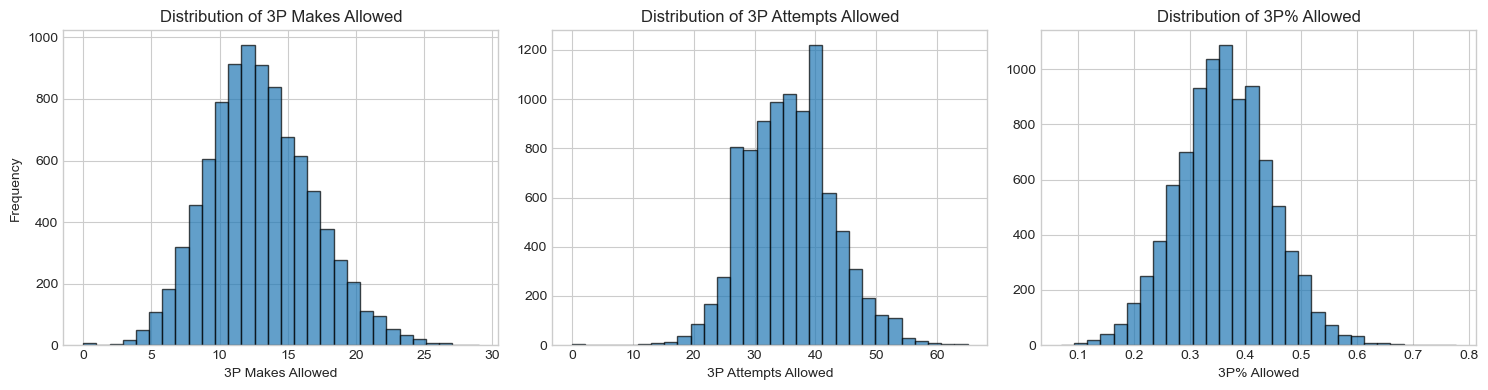

,threes_made,threes_att,three_percentage
count,9158.000000,9158.000000,9152.000000
mean,12.945403,35.666739,0.362313
std,3.968048,7.154689,0.083001
min,0.000000,0.000000,0.068966
25%,10.000000,31.000000,0.307692
50%,13.000000,35.000000,0.361111
75%,16.000000,40.000000,0.416667
max,29.000000,65.000000,0.777778


In [8]:
# 1a. Distribution of raw 3P makes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw makes
axes[0].hist(shooting['threes_made'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('3P Makes Allowed')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of 3P Makes Allowed')

# Attempts
axes[1].hist(shooting['threes_att'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('3P Attempts Allowed')
axes[1].set_title('Distribution of 3P Attempts Allowed')

# Efficiency (3P%)
axes[2].hist(shooting['three_percentage'], bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('3P% Allowed')
axes[2].set_title('Distribution of 3P% Allowed')

plt.tight_layout()
plt.show()

# Summary stats
shooting[['threes_made', 'threes_att', 'three_percentage']].describe()

In [9]:
# 1b. Residual metric construction
# Rolling 10-game average with cold start adjustment (use last year's first 15 games)

def calculate_rolling_residual(df, col, window=10, last_year_col=None):
    """
    Calculate rolling residual with cold start handling.
    For first N games of season, use blended prior from last year's early games.
    
    Parameters:
    - df: DataFrame sorted by team and date
    - col: Column to calculate residual for
    - window: Rolling window size
    - last_year_col: Column with last year's early season average (first 15 games)
    """
    # Shift to avoid leakage (use games 1 to N-1 to predict game N)
    rolling_avg = df.groupby('team_id')[col].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    
    # For cold start: blend with prior
    # Weight current season more as sample grows
    if last_year_col is not None:
        game_num = df.groupby(['team_id', 'season']).cumcount() + 1
        weight = np.minimum(game_num / window, 1.0)
        rolling_avg = weight * rolling_avg + (1 - weight) * df[last_year_col]
    
    residual = df[col] - rolling_avg
    return rolling_avg, residual

# Example usage:
# df['fg3_pct_rolling'], df['fg3_pct_residual'] = calculate_rolling_residual(
#     df, 'fg3_pct_allowed', window=10, last_year_col='last_year_early_fg3_pct'
# )

In [10]:
def wma (df,min,periods,col,grping):
    df['{}Mv'.format(col)] = df.groupby(grping)[col].transform(
            lambda x: x.rolling(periods, closed='left', min_periods=min, win_type='exponential').mean()
        )
    return df

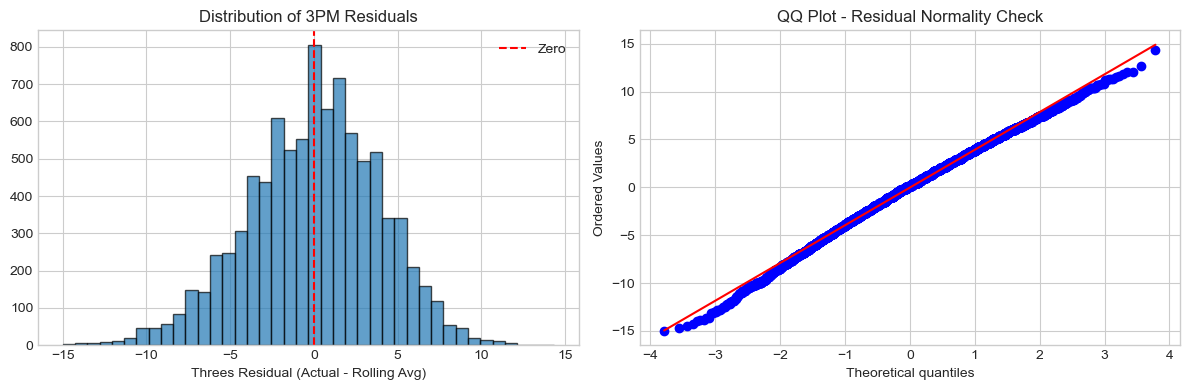

In [141]:
# 1c. Distribution of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residual distribution - should be roughly normal, centered near 0
axes[0].hist(shooting['three_residual'], bins=40, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='Zero')
axes[0].set_xlabel('Threes Residual (Actual - Rolling Avg)')
axes[0].set_title('Distribution of 3PM Residuals')
axes[0].legend()

# QQ plot to check normality
stats.probplot(shooting['three_residual'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot - Residual Normality Check')

plt.tight_layout()
plt.show()

---
## 2. Sample Size vs Variance - Understand Noise Floor

In [138]:
# 2a. Variance as function of 3PA
# Bin by attempt volume, calculate variance within each bin

def variance_by_attempts(df, attempt_col, pct_col, n_bins=10):
    """
    Calculate 3P% variance within attempt volume bins.
    Validates how much to trust single-game metrics.
    """
    df_temp = df[[attempt_col, pct_col]].dropna().copy()
    df_temp['attempt_bin'] = pd.qcut(df_temp[attempt_col],q=n_bins, duplicates='drop')
    
    variance_by_bin = df_temp.groupby('attempt_bin',observed=False)[pct_col].agg(['var', 'std', 'count', 'mean'])
    variance_by_bin['bin_midpoint'] = df_temp.groupby('attempt_bin',observed=False)[attempt_col].mean()
    
    return variance_by_bin

variance_df = variance_by_attempts(shooting, 'threes_made', 'threes_att',n_bins = 15)
print(variance_df)

                     var       std  count       mean  bin_midpoint
attempt_bin                                                       
(-0.001, 7.0]  37.859273  6.152989    685  26.921168      6.016058
(7.0, 9.0]     26.065077  5.105397   1060  30.355660      8.569811
(9.0, 10.0]    26.196214  5.118224    791  32.035398     10.000000
(10.0, 11.0]   25.989585  5.097998    915  33.431694     11.000000
(11.0, 12.0]   26.503335  5.148139    974  34.390144     12.000000
(12.0, 13.0]   26.697078  5.166922    910  36.019780     13.000000
(13.0, 14.0]   30.064816  5.483139    840  36.904762     14.000000
(14.0, 15.0]   24.235309  4.922937    675  38.238519     15.000000
(15.0, 16.0]   25.113082  5.011295    616  39.136364     16.000000
(16.0, 17.0]   29.327071  5.415447    502  40.754980     17.000000
(17.0, 19.0]   29.688038  5.448673    654  42.738532     18.425076
(19.0, 29.0]   33.716721  5.806610    536  45.680970     21.513060


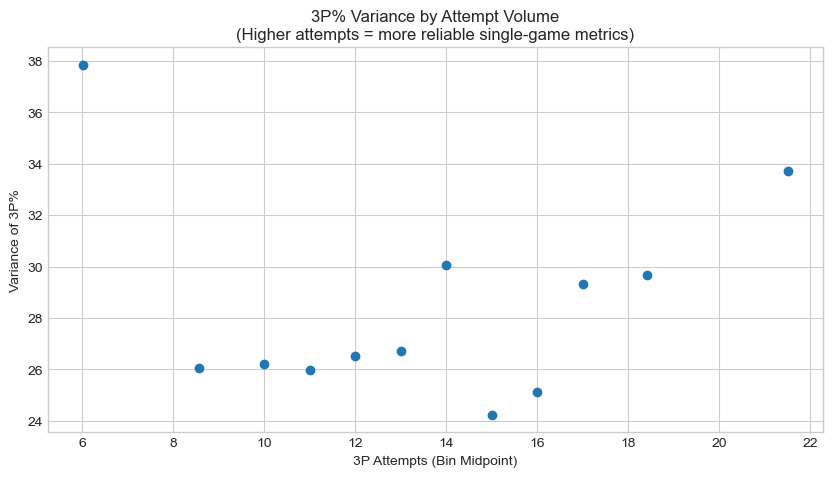

In [139]:
# 2b. Plot variance vs attempts
fig, ax = plt.subplots(figsize=(10, 5))

# Expected: variance decreases as attempts increase (binomial variance = p(1-p)/n)
ax.scatter(variance_df['bin_midpoint'], variance_df['var'])
ax.set_xlabel('3P Attempts (Bin Midpoint)')
ax.set_ylabel('Variance of 3P%')
ax.set_title('3P% Variance by Attempt Volume\n(Higher attempts = more reliable single-game metrics)')

# Overlay theoretical binomial variance curve
x_theory = np.linspace(10, 50, 100)
p_avg = shooting['three_percentage'].mean()
y_theory = p_avg * (1 - p_avg) / x_theory
#ax.plot(x_theory, y_theory, 'r--', label=f'Theoretical (p={p_avg:.3f})')


plt.show()

---
## 3. Feature Correlations - Check Multicollinearity

In [29]:
team = pd.read_sql('''
                SELECT game_id, game_date, team_id, home, attendance, sc_points_allowed, fb_points_allowed,to_points_allowed,
                bp_allowed, attendance / (stad_capacity * 1.0) as fill_capacity

                FROM teamLog tl
                JOIN teams t USING (team_id)''',etl.conn)
team['fill_capacity'] = team.groupby('game_id').fill_capacity.transform('max')

In [52]:
pl = etl.get_logs(['2026-03-01'])

started player logs at 09:11


In [64]:
temp

,PLAYER_ID,PLAYER_NAME,PLAYER_LAST_TEAM_ID,PLAYER_LAST_TEAM_ABBREVIATION,AGE,GP,G,FGA_FREQUENCY,FGM,FGA,FG_PCT,EFG_PCT,FG2A_FREQUENCY,FG2M,FG2A,FG2_PCT,FG3A_FREQUENCY,FG3M,FG3A,FG3_PCT
0,1630168,Onyeka Okongwu,1610612737,ATL,25.0,1,1,0.800,7,12,0.583,0.875,0.000,0,0,NaN,0.800,7,12,0.583
1,1642885,Mohamed Diawara,1610612752,NYK,20.0,1,1,0.857,4,12,0.333,0.500,0.000,0,0,NaN,0.857,4,12,0.333
2,1630530,Trey Murphy III,1610612740,NOP,25.0,1,1,0.600,3,9,0.333,0.500,0.000,0,0,NaN,0.600,3,9,0.333
3,1631248,Baylor Scheierman,1610612738,BOS,25.0,1,1,0.667,2,8,0.250,0.313,0.083,1,1,1.0,0.583,1,7,0.143
4,1642874,Danny Wolf,1610612751,BKN,21.0,1,1,0.538,3,7,0.429,0.643,0.000,0,0,NaN,0.538,3,7,0.429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,1629661,Cameron Johnson,1610612743,DEN,30.0,1,1,0.200,0,1,0.000,0.000,0.000,0,0,NaN,0.200,0,1,0.000
167,1630549,Day'Ron Sharpe,1610612751,BKN,24.0,1,1,0.200,0,1,0.000,0.000,0.000,0,0,NaN,0.200,0,1,0.000
168,1642450,Daniss Jenkins,1610612765,DET,24.0,1,1,0.167,0,1,0.000,0.000,0.000,0,0,NaN,0.167,0,1,0.000
169,1629162,Jordan McLaughlin,1610612759,SAS,29.0,1,1,0.500,0,1,0.000,0.000,0.000,0,0,NaN,0.500,0,1,0.000


In [ ]:
openness = ['6+ Feet - Wide Open','4-6 Feet - Open','2-4 Feet - Tight','0-2 Feet - Very Tight']
final = pd.DataFrame()
for ct, date in enumerate((['2026-03-01'])):
    d = pd.to_datetime(date)
    season = '{}-{}'.format(d.year, str(d.year + 1)[-2:]) if d.month >= 10 else '{}-{}'.format(d.year - 1, str(d.year)[-2:])
    shots = pd.DataFrame()
    for op in openness:
        temp = LeagueDashPlayerPtShot(date_from_nullable=date,
                                          date_to_nullable=date,
                                          season=season,
                                          close_def_dist_range_nullable=op
                                          , timeout=60).get_data_frames()[0]
        time.sleep(np.random.randint(2, 8))
        df = temp.filter([col for col in drbShots.columns if re.search('[2-3][A|M]$|ID$', col) != None])
        df.columns = [
            '{}_{}'.format(op.replace(' ', '_'), col) if re.search('ID$', col) == None else col for
            col in df.columns]
        shots = pd.concat([drb, df])
        shots['GAME_DATE'] = date
    shots = shots.groupby(['PLAYER_ID', 'GAME_DATE', 'PLAYER_LAST_TEAM_ID']).sum().reset_index()
    final = pd.concat([final, drb])

In [56]:
from nba_api.stats.endpoints import LeagueDashPlayerPtShot
LeagueDashPlayerPtShot(
			pt_measure_type='shooting',
			player_or_team='Player',
			#close_def_dist_range_nullable='6+ Feet - Wide Open',
			date_from_nullable='2026-03-01',
			date_to_nullable='2026-03-01',
			season='2026-26'
		).get_data_frames()[0]


In [ ]:
# 3a. Correlation matrix of defensive features
feature_cols = [
    'rim_protection',        # e.g., FG% allowed at rim - create 
    'drives_allowed',        # drives per possession
    'corner_3_pct_residual', # corner 3 % vs expected
    'fg3a_per_poss_residual',# 3PA volume vs expected
    'expected_shot_quality', # quality-weighted shooter skill
    'attendance_pct',        # crowd pressure proxy
    'fg3_pct_allowed',       # target variable
]

# corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
#             fmt='.2f', square=True, ax=ax)
ax.set_title('Feature Correlation Matrix\n(Watch for |r| > 0.7 between predictors)')
plt.tight_layout()
plt.show()

In [ ]:
# 3b. Variance Inflation Factor (VIF) for multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, feature_cols):
    """
    Calculate VIF for each feature.
    VIF > 5 suggests problematic multicollinearity.
    VIF > 10 is severe.
    """
    X = df[feature_cols].dropna()
    vif_data = pd.DataFrame()
    vif_data['feature'] = feature_cols
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(feature_cols))]
    return vif_data.sort_values('VIF', ascending=False)

# Exclude target variable from VIF calculation
# predictor_cols = [c for c in feature_cols if c != 'fg3_pct_allowed']
# vif_df = calculate_vif(df, predictor_cols)
# print(vif_df)

---
## 4. Predictive Validation of Residuals
Does the rolling residual predict *next* game better than raw?

In [193]:
comdf = shooting.copy()

In [194]:
comdf = comdf[['game_date','team_id','team','three_residual','home','wide_fg3a','wide_fg3m','open_fg3m','open_fg3a','threes_made']]

In [205]:
comdf['rThreeResid'] = comdf.sort_values(by='game_date').groupby(['team_id','season']).three_residual.rolling(10,closed='left').mean().reset_index(drop=True)

KeyError: 'season'

In [196]:
comdf = data.weighted_moving_avg(comdf,10,10,'three_residual','team_id')

In [197]:
lr = sm.OLS(comdf.dropna().threes_made,comdf.dropna().three_residualMv)

In [198]:
results = lr.fit()

In [200]:
print('Weighted Moving Average')
results.summary()

Weighted Moving Average


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            threes_made   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):              0.001
Method:                 Least Squares   F-statistic:                              11.22
Date:                Tue, 10 Mar 2026   Prob (F-statistic):                    0.000814
Time:                        07:37:12   Log-Likelihood:                         -30138.
No. Observations:                7481   AIC:                                  6.028e+04
Df Residuals:                    7480   BIC:                                  6.028e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
three_residualMv    -0.2536      0.076     -3.349      0.001      -0.402      -0.105
==============================================================================
Omnibus:                      112.444   Durbin-Watson:                   0.166
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              117.200
Skew:                           0.304   Prob(JB):                     3.55e-26
Kurtosis:                       3.072   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [204]:
print(mean_absolute_error(comdf.dropna().threes_made,comdf.dropna().rThreeResid))
print(r2_score(comdf.dropna().threes_made,comdf.dropna().rThreeResid))

13.031369023749052
-10.915839818344189


In [202]:
print(mean_absolute_error(comdf.dropna().threes_made,comdf.dropna().three_residualMv))
print((r2_score(comdf.dropna().threes_made,comdf.dropna().three_residualMv)))

13.022916679820591
-11.016479873512946


In [189]:
lrM = sm.OLS(comdf.dropna().threes_made,comdf.dropna().rThreeResid)
resultsM = lrM.fit()
resultsM.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            threes_made   R-squared (uncentered):                   0.002
Model:                            OLS   Adj. R-squared (uncentered):              0.002
Method:                 Least Squares   F-statistic:                              20.51
Date:                Tue, 10 Mar 2026   Prob (F-statistic):                    6.02e-06
Time:                        07:33:57   Log-Likelihood:                         -33131.
No. Observations:                8229   AIC:                                  6.626e+04
Df Residuals:                    8228   BIC:                                  6.627e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
rThreeResid    -0.3461      0.076     -4.529      0.000      -0.496      -0.196
==============================================================================
Omnibus:                      128.098   Durbin-Watson:                   0.173
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              133.779
Skew:                           0.308   Prob(JB):                     8.92e-30
Kurtosis:                       3.098   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [134]:
# 4a. Compare predictive power: rolling avg vs raw
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

def compare_predictive_power(df, actual_col, rolling_col, raw_prior_col=None, window=15):
    """
    Compare how well rolling average predicts next game vs simpler alternatives.
    """
    meanCol = df.sort_values(by='game_date').groupby('team_id')[col].rolling(window).mean()
    expCol = df.sort_values(by='game_date').groupby('team_id')[col].rolling(window).mean()
    df_valid = df[[meanCol, expCol]].dropna()
    
    results = {}
    
    # Rolling average prediction
    results['rolling_10'] = {
        'MAE': mean_absolute_error(df_valid[meanCol], df_valid[expCol]),
        'RMSE': np.sqrt(mean_squared_error(df_valid[meanCol], df_valid[expCol])),
        'R2': r2_score(df_valid[meanCol], df_valid[expCol])
    }
    
    # Naive baseline: just use overall mean
    overall_mean = df_valid[meanCol].mean()
    results['overall_mean'] = {
        'MAE': mean_absolute_error(df_valid[meanCol], [overall_mean] * len(df_valid)),
        'RMSE': np.sqrt(mean_squared_error(df_valid[meanCol], [overall_mean] * len(df_valid))),
        'R2': 0.0  # by definition
    }
    
    return pd.DataFrame(results).T

# predictive_comparison = compare_predictive_power(df, col)
# print(predictive_comparison)

In [79]:
mvMakes = df.groupby(['team','season']).threesMade.rolling(window=15,min_periods=5,closed='left').sum().reset_index().set_index('level_2').drop(['season','team'],axis=1)
expMakes = df.groupby(['team','season']).threesMade.rolling(window=15,min_periods=5,closed='left',win_type='exponential').sum().reset_index().set_index('level_2').drop(['season','team'],axis=1)

In [80]:
mvAtts =df.groupby(['team','season']).threes_fga.rolling(window=15,min_periods=5,closed='left').sum().reset_index().set_index('level_2').drop(['season','team'],axis=1)
expAtts =df.groupby(['team','season']).threes_fga.rolling(window=15,min_periods=5,closed='left',win_type='exponentail').sum().reset_index().set_index('level_2').drop(['season','team'],axis=1)


In [81]:
df['strRateMv'] = mvMakes.values / mvAtts.values
df['expRateMv'] = expMakes.values / expAtts.values

In [94]:
pd.read_sql('''
select * from shotsAllowed 
where game_date in 
('2025-11-07', '2025-11-21', '2024-12-13', '2024-12-16', '2024-12-12',
       '2024-12-11', '2024-12-14', '2024-12-10', '2024-12-09', '2025-01-26')
''',etl.conn)

,team_id,game_date,game_id,ra_fgm,ra_fga,paint_fgm,paint_fga,mid_fgm,mid_fga,lc_fgm,lc_fga,rc_fgm,rc_fga,abv_fgm,abv_fga,crn_fgm,crn_fga,wide_fg2m,wide_fg2a,wide_fg3m,wide_fg3a,open_fg2m,open_fg2a,open_fg3m,open_fg3a,drb0_fg2m,drb0_fg2a,drb0_fg3m,drb0_fg3a,drb1_fg2m,drb1_fg2a,drb1_fg3m,drb1_fg3a,drb2_fg2m,drb2_fg2a,drb2_fg3m,drb2_fg3a,drb36_fg2m,drb36_fg2a,drb36_fg3m,drb36_fg3a,drb7_fg2m,drb7_fg2a,drb7_fg3m,drb7_fg3a
0,1610612761,2024-12-09,0022400359,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1610612752,2024-12-09,0022400359,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1610612749,2024-12-10,0022401201,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1610612760,2024-12-10,0022401203,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1610612753,2024-12-10,0022401201,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,1610612740,2025-11-21,0022500052,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
86,1610612750,2025-11-21,0022500053,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
87,1610612743,2025-11-21,0022500054,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
88,1610612760,2025-11-21,0022500055,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [101]:
df[df.threesMade==0].game_date.value_counts()

game_date
2025-11-07    22
2025-11-21    18
2024-12-13    16
2024-12-16    12
2024-12-12     6
2024-12-11     4
2024-12-14     4
2024-12-10     4
2024-12-09     2
2025-01-26     2
Name: count, dtype: int64

In [93]:
df[df.threesMade==0].game_date.value_counts().index

Index(['2025-11-07', '2025-11-21', '2024-12-13', '2024-12-16', '2024-12-12',
       '2024-12-11', '2024-12-14', '2024-12-10', '2024-12-09', '2025-01-26'],
      dtype='object', name='game_date')

2022-23 season
Mean: 12.30


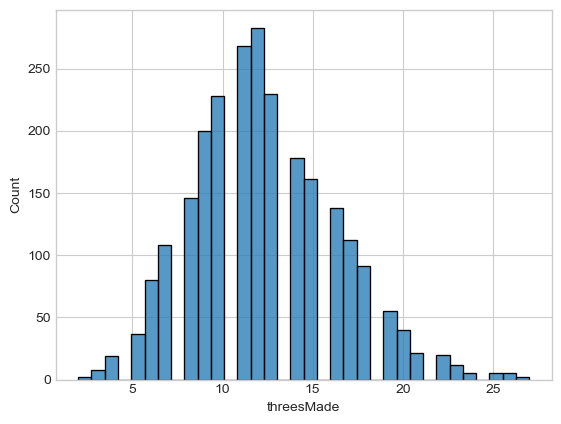

2023-24 season
Mean: 12.80


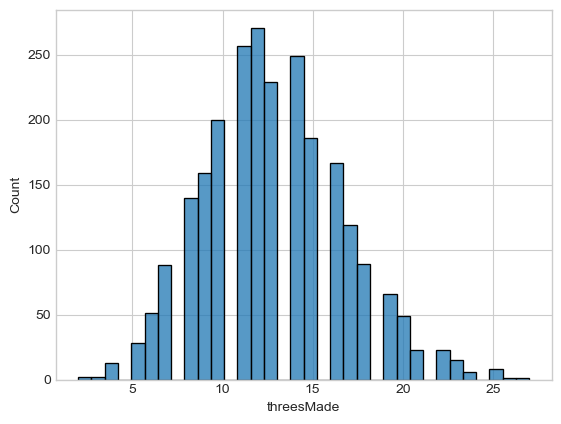

2024-25 season
Mean: 13.26


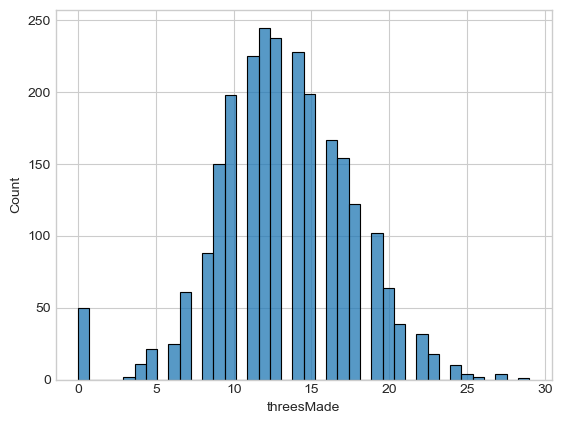

2025-26 season
Mean: 12.96


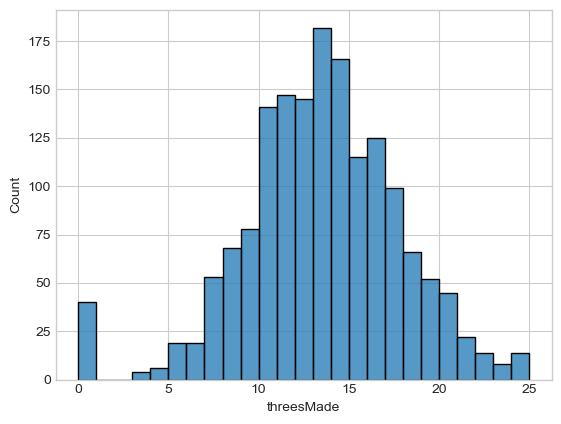

2024-26 season
Mean: 11.50


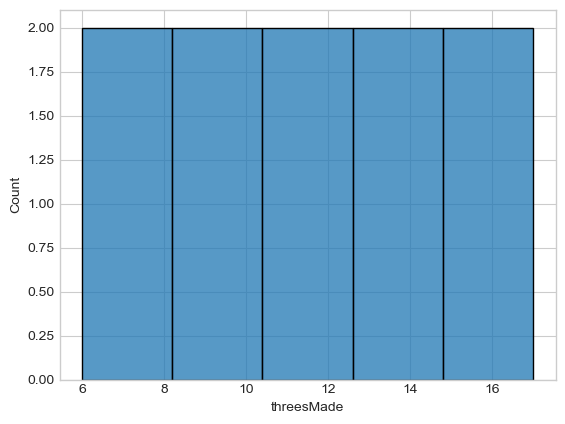

2021-23 season
Mean: 11.83


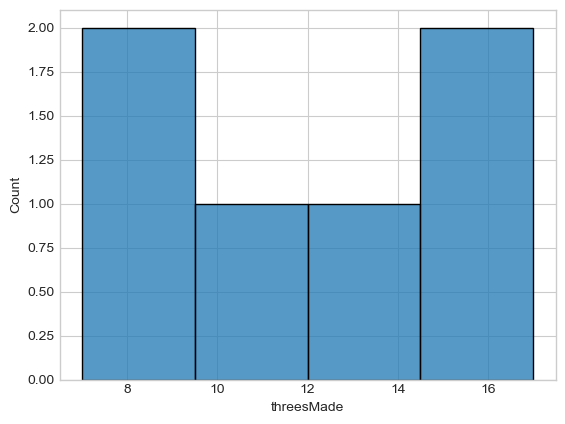

2022-24 season
Mean: 11.31


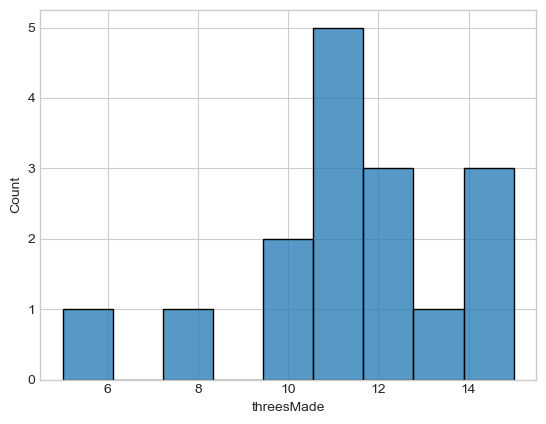

In [89]:
for season in df.season.unique():
    temp = df[df.season==season]
    print('{} season\nMean: {:.2f}'.format(season,temp.threesMade.mean()))
    sns.histplot(temp.threesMade)
    plt.show()

In [ ]:
# 4b. Test different window sizes
def test_window_sizes(df, col, windows=[5, 10, 15, 20]):
    """
    Compare predictive accuracy across different rolling window sizes.
    """
    results = []
    
    for w in windows:
        rolling = df.groupby('team_id')[col].transform(
            lambda x: x.shift(1).rolling(window=w, min_periods=1).mean()
        )
        
        valid_mask = ~rolling.isna() & ~df[col].isna()
        mae = mean_absolute_error(df.loc[valid_mask, col], rolling[valid_mask])
        
        results.append({'window': w, 'MAE': mae})
    
    return pd.DataFrame(results)

# window_comparison = test_window_sizes(df, 'fg3_pct_allowed')
# print(window_comparison)

---
## 5. Time Series + Autocorrelation
Is defensive 3P% allowed AR(1)? AR(3)? Informs rolling window choice.

In [ ]:
# 5a. Autocorrelation analysis for a single team
def plot_team_autocorrelation(df, team_id, col, lags=20):
    """
    Plot ACF and PACF for a team's defensive 3P% time series.
    """
    team_data = df[df['team_id'] == team_id][col].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    plot_acf(team_data, lags=lags, ax=axes[0])
    axes[0].set_title(f'Autocorrelation - Team {team_id}')
    
    plot_pacf(team_data, lags=lags, ax=axes[1])
    axes[1].set_title(f'Partial Autocorrelation - Team {team_id}')
    
    plt.tight_layout()
    plt.show()

# plot_team_autocorrelation(df, team_id=1610612744, col='fg3_pct_allowed')  # GSW example

In [ ]:
# 5b. Average autocorrelation across all teams
def average_autocorrelation(df, col, lags=15):
    """
    Calculate average ACF across all teams to find typical lag structure.
    """
    all_acfs = []
    
    for team_id in df['team_id'].unique():
        team_data = df[df['team_id'] == team_id][col].dropna()
        if len(team_data) > lags + 5:
            team_acf = acf(team_data, nlags=lags, fft=False)
            all_acfs.append(team_acf)
    
    avg_acf = np.mean(all_acfs, axis=0)
    std_acf = np.std(all_acfs, axis=0)
    
    return pd.DataFrame({
        'lag': range(lags + 1),
        'avg_acf': avg_acf,
        'std_acf': std_acf
    })

# acf_summary = average_autocorrelation(df, 'fg3_pct_allowed')
# print(acf_summary)

In [ ]:
# 5c. Time series visualization - offensive vs defensive fluctuations
def plot_offense_defense_timeseries(df, team_id, n_games=50):
    """
    Plot offensive and defensive 3P% over time for a single team.
    Look for: Are fluctuations explained by opponent quality?
    """
    team_data = df[df['team_id'] == team_id].head(n_games).copy()
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Defensive 3P% allowed
    # axes[0].plot(team_data['game_date'], team_data['fg3_pct_allowed'], 
    #              'b-', label='Actual', alpha=0.7)
    # axes[0].plot(team_data['game_date'], team_data['fg3_pct_rolling'], 
    #              'r--', label='Rolling 10', alpha=0.7)
    axes[0].set_ylabel('3P% Allowed')
    axes[0].set_title('Defensive 3P% Over Time')
    axes[0].legend()
    
    # Overlay opponent offensive rating or 3P%
    # ax0_twin = axes[0].twinx()
    # ax0_twin.scatter(team_data['game_date'], team_data['opp_season_3p_pct'], 
    #                  c='green', alpha=0.4, s=20, label='Opp Season 3P%')
    # ax0_twin.set_ylabel('Opponent 3P%', color='green')
    
    # Residuals
    # axes[1].bar(team_data['game_date'], team_data['fg3_pct_residual'], 
    #             color=['green' if x < 0 else 'red' for x in team_data['fg3_pct_residual']],
    #             alpha=0.7)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_ylabel('Residual')
    axes[1].set_xlabel('Game Date')
    axes[1].set_title('Residuals (Actual - Expected)\nGreen = Better than expected')
    
    plt.tight_layout()
    plt.show()

# plot_offense_defense_timeseries(df, team_id=1610612744)

---
## 6. Bivariate Relationships to Outcome

In [ ]:
# 6a. Scatter plots of each feature vs 3P% allowed
def plot_bivariate_relationships(df, feature_cols, target_col, ncols=3):
    """
    Create scatter plots of each feature vs target with regression line.
    """
    nrows = int(np.ceil(len(feature_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        
        # Remove NAs for this pair
        valid = df[[col, target_col]].dropna()
        
        ax.scatter(valid[col], valid[target_col], alpha=0.3, s=10)
        
        # Add regression line
        if len(valid) > 2:
            z = np.polyfit(valid[col], valid[target_col], 1)
            p = np.poly1d(z)
            x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
            ax.plot(x_line, p(x_line), 'r-', linewidth=2)
            
            # Correlation
            r = valid[col].corr(valid[target_col])
            ax.set_title(f'{col}\nr = {r:.3f}')
        
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
    
    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# predictor_cols = ['rim_protection', 'drives_allowed', 'corner_3_pct_residual', 
#                   'fg3a_per_poss_residual', 'expected_shot_quality', 'attendance_pct']
# plot_bivariate_relationships(df, predictor_cols, 'fg3_pct_allowed')

In [ ]:
# 6b. Partial correlations controlling for pace/opponent
def partial_correlation(df, x_col, y_col, control_cols):
    """
    Calculate partial correlation between x and y, controlling for other variables.
    """
    from sklearn.linear_model import LinearRegression
    
    valid = df[[x_col, y_col] + control_cols].dropna()
    
    # Residualize x
    reg_x = LinearRegression().fit(valid[control_cols], valid[x_col])
    resid_x = valid[x_col] - reg_x.predict(valid[control_cols])
    
    # Residualize y
    reg_y = LinearRegression().fit(valid[control_cols], valid[y_col])
    resid_y = valid[y_col] - reg_y.predict(valid[control_cols])
    
    # Correlation of residuals
    return np.corrcoef(resid_x, resid_y)[0, 1]

# Example: correlation between rim protection and 3P% allowed, controlling for pace
# partial_r = partial_correlation(df, 'rim_protection', 'fg3_pct_allowed', ['pace', 'opp_season_3p_pct'])
# print(f"Partial correlation: {partial_r:.3f}")

---
## 7. Splits Analysis - Find Confounders/Additional Features

In [ ]:
# 7a. Home vs Away splits
def analyze_home_away_split(df, col):
    """
    Compare metric distributions for home vs away games.
    """
    home = df[df['is_home'] == True][col].dropna()
    away = df[df['is_home'] == False][col].dropna()
    
    # T-test
    t_stat, p_val = stats.ttest_ind(home, away)
    
    summary = pd.DataFrame({
        'Home': [home.mean(), home.std(), len(home)],
        'Away': [away.mean(), away.std(), len(away)],
        'Diff': [home.mean() - away.mean(), np.nan, np.nan]
    }, index=['Mean', 'Std', 'N'])
    
    print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
    return summary

# home_away = analyze_home_away_split(df, 'fg3_pct_allowed')
# print(home_away)

In [ ]:
# 7b. Rest days impact
def analyze_rest_impact(df, col):
    """
    Analyze how rest days affect the metric.
    """
    rest_summary = df.groupby('rest_days')[col].agg(['mean', 'std', 'count'])
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(rest_summary.index, rest_summary['mean'], yerr=rest_summary['std']/np.sqrt(rest_summary['count']))
    ax.set_xlabel('Days of Rest')
    ax.set_ylabel(col)
    ax.set_title(f'{col} by Rest Days\n(Error bars = SE)')
    plt.show()
    
    return rest_summary

# rest_analysis = analyze_rest_impact(df, 'fg3_pct_allowed')

In [ ]:
# 7c. Opponent tier analysis
def analyze_opponent_tiers(df, col, tier_col='opp_tier'):
    """
    Analyze metric by opponent quality tier.
    Tier could be based on opponent offensive rating, win%, etc.
    """
    # Create tiers if not present
    # df['opp_tier'] = pd.qcut(df['opp_offensive_rating'], q=3, labels=['Bottom', 'Middle', 'Top'])
    
    tier_summary = df.groupby(tier_col)[col].agg(['mean', 'std', 'count'])
    
    fig, ax = plt.subplots(figsize=(8, 5))
    tier_summary['mean'].plot(kind='bar', yerr=tier_summary['std']/np.sqrt(tier_summary['count']), ax=ax)
    ax.set_ylabel(col)
    ax.set_title(f'{col} by Opponent Tier\n(Validates if opponent strength is a confounder)')
    plt.xticks(rotation=0)
    plt.show()
    
    return tier_summary

# tier_analysis = analyze_opponent_tiers(df, 'fg3_pct_allowed')

---
## 8. Attendance % Analysis - Crowd Pressure Proxy

In [ ]:
# 8a. Attendance % distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of attendance %
# axes[0].hist(df['attendance_pct'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Attendance %')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Attendance %')

# Check for threshold effects (95%+ might be what matters)
# axes[1].hist(df['attendance_pct'], bins=[0.5, 0.7, 0.8, 0.9, 0.95, 1.0, 1.05], 
#              edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Attendance % Bins')
axes[1].set_title('Attendance % Distribution (Binned)')

plt.tight_layout()
plt.show()

In [ ]:
# 8b. Attendance vs 3P% - is relationship linear or threshold-based?
def analyze_attendance_relationship(df, attendance_col, shooting_col):
    """
    Analyze attendance impact on shooting percentage.
    Check: linear relationship vs threshold effect.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter with lowess
    valid = df[[attendance_col, shooting_col]].dropna()
    axes[0].scatter(valid[attendance_col], valid[shooting_col], alpha=0.2, s=10)
    
    # Add lowess smooth
    from statsmodels.nonparametric.smoothers_lowess import lowess
    smooth = lowess(valid[shooting_col], valid[attendance_col], frac=0.3)
    axes[0].plot(smooth[:, 0], smooth[:, 1], 'r-', linewidth=2, label='LOWESS')
    
    axes[0].set_xlabel('Attendance %')
    axes[0].set_ylabel(shooting_col)
    axes[0].set_title('Attendance vs 3P% (LOWESS smooth)\nLook for nonlinearity')
    axes[0].legend()
    
    # Binned means
    df_temp = valid.copy()
    df_temp['att_bin'] = pd.cut(df_temp[attendance_col], bins=10)
    binned = df_temp.groupby('att_bin')[shooting_col].agg(['mean', 'std', 'count'])
    binned['se'] = binned['std'] / np.sqrt(binned['count'])
    
    x_pos = range(len(binned))
    axes[1].bar(x_pos, binned['mean'], yerr=binned['se'], alpha=0.7)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(x)[:10] for x in binned.index], rotation=45, ha='right')
    axes[1].set_xlabel('Attendance % Bin')
    axes[1].set_ylabel(f'Mean {shooting_col}')
    axes[1].set_title('Binned Attendance Effect\nLook for threshold at high attendance')
    
    plt.tight_layout()
    plt.show()

# analyze_attendance_relationship(df, 'attendance_pct', 'fg3_pct_allowed')

In [ ]:
# 8c. Home vs Away attendance effect asymmetry
def attendance_home_away_asymmetry(df, attendance_col, shooting_col):
    """
    Check if crowd pressure affects home vs away teams differently.
    Hypothesis: Road crowd pressure affects visiting shooters more.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, (is_home, label) in enumerate([(True, 'Home'), (False, 'Away')]):
        subset = df[df['is_home'] == is_home][[attendance_col, shooting_col]].dropna()
        
        axes[i].scatter(subset[attendance_col], subset[shooting_col], alpha=0.2, s=10)
        
        # Regression line
        z = np.polyfit(subset[attendance_col], subset[shooting_col], 1)
        p = np.poly1d(z)
        x_line = np.linspace(subset[attendance_col].min(), subset[attendance_col].max(), 100)
        axes[i].plot(x_line, p(x_line), 'r-', linewidth=2)
        
        r = subset[attendance_col].corr(subset[shooting_col])
        slope = z[0]
        axes[i].set_title(f'{label} Games\nr = {r:.3f}, slope = {slope:.4f}')
        axes[i].set_xlabel('Attendance %')
        axes[i].set_ylabel(shooting_col)
    
    plt.tight_layout()
    plt.show()

# attendance_home_away_asymmetry(df, 'attendance_pct', 'fg3_pct_allowed')

In [ ]:
# 8d. Within-team attendance effect (controls for team quality confound)
def within_team_attendance_effect(df, attendance_col, shooting_col):
    """
    For each team, calculate correlation between attendance and shooting.
    If relationship holds within-team (same roster, varying attendance), 
    that's stronger evidence than pooled correlation.
    """
    team_correlations = []
    
    for team_id in df['team_id'].unique():
        team_data = df[df['team_id'] == team_id][[attendance_col, shooting_col]].dropna()
        if len(team_data) > 10:
            r = team_data[attendance_col].corr(team_data[shooting_col])
            team_correlations.append({'team_id': team_id, 'r': r, 'n': len(team_data)})
    
    team_corr_df = pd.DataFrame(team_correlations)
    
    # Distribution of within-team correlations
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(team_corr_df['r'], bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--', label='Zero')
    ax.axvline(x=team_corr_df['r'].mean(), color='blue', linestyle='-', 
               label=f'Mean r = {team_corr_df["r"].mean():.3f}')
    ax.set_xlabel('Within-Team Correlation')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Within-Team Attendance-Shooting Correlations\n(If mean > 0, attendance effect holds within teams)')
    ax.legend()
    plt.show()
    
    # T-test: is mean correlation significantly different from 0?
    t_stat, p_val = stats.ttest_1samp(team_corr_df['r'], 0)
    print(f"Mean within-team correlation: {team_corr_df['r'].mean():.3f}")
    print(f"T-test vs 0: t={t_stat:.3f}, p={p_val:.4f}")
    
    return team_corr_df

# within_team = within_team_attendance_effect(df, 'attendance_pct', 'fg3_pct_allowed')

In [ ]:
# 8e. Simple attendance forecasting model for feature engineering
# This creates predicted attendance to use as a feature (avoiding leakage)

def create_attendance_features(df):
    """
    Create lagged attendance features for forecasting.
    Features: rolling attendance, team win %, opponent win %, month, day of week
    """
    df = df.copy()
    
    # Rolling attendance (shifted to avoid leakage)
    df['attendance_rolling_5'] = df.groupby('team_id')['attendance_pct'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
    
    # Team win % (up to previous game)
    # df['team_win_pct'] = ...
    
    # Opponent win % (season to date)
    # df['opp_win_pct'] = ...
    
    # Temporal features
    # df['month'] = df['game_date'].dt.month
    # df['day_of_week'] = df['game_date'].dt.dayofweek
    
    return df

# df = create_attendance_features(df)

---
## Summary & Next Steps

After completing EDA, document:
1. Which features show strongest relationship to 3P% allowed?
2. What's the optimal rolling window based on autocorrelation?
3. Are there multicollinearity issues to address?
4. Does attendance % show significant effect after controlling for team quality?
5. What splits (home/away, rest, opponent tier) should be features vs controls?

In [ ]:
# Summary statistics for key decisions
summary_stats = {
    # 'optimal_rolling_window': ,  # From section 4b
    # 'high_vif_features': [],      # From section 3b
    # 'attendance_effect_significant': ,  # From section 8d
    # 'home_away_diff_significant': ,     # From section 7a
}

# print(summary_stats)